# Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)



# Q1 Logistic Regression Intution

What is logistic regression, and why is it used instead of linear regression when the target variable is categorical (e.g. malignant vs. benign) rather than continuous? Define the sigmoid function `sigmoid(z) = 1 / (1 + e⁻ᶻ)` and explain how it transforms the output of a linear equation into something usable as a probability.


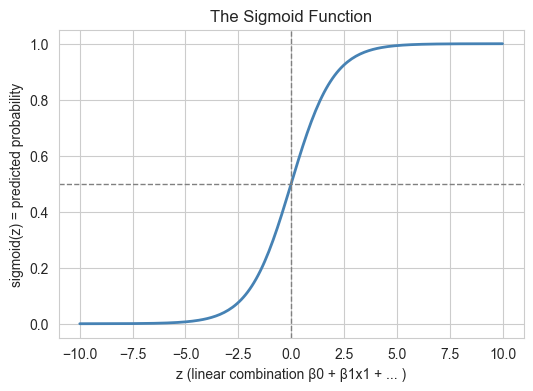

sigmoid(-10) = 0.000045
sigmoid(0)   = 0.500000
sigmoid(10)  = 0.999955


In [2]:
# Visualize the sigmoid function to build intuition
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
p = sigmoid(z)

plt.figure(figsize=(6, 4))
plt.plot(z, p, color='steelblue', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("z (linear combination β0 + β1x1 + ... )")
plt.ylabel("sigmoid(z) = predicted probability")
plt.title("The Sigmoid Function")
plt.show()

print(f"sigmoid(-10) = {sigmoid(-10):.6f}")
print(f"sigmoid(0)   = {sigmoid(0):.6f}")
print(f"sigmoid(10)  = {sigmoid(10):.6f}")


## Q2. Load and Explore the Dataset
Load the Breast Cancer Wisconsin dataset and explore it. Report the shape of the data, the list of feature names, and the class balance of `target` (counts and percentages). Based on the class balance, would accuracy alone be a trustworthy metric for this dataset? Why or why not?


In [5]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the breast cancer dataset
data = load_breast_cancer()

# Create a DataFrame for features
X = pd.DataFrame(data.data, columns=data.feature_names)

# Create a Series for the target
y = pd.Series(data.target, name="target")

# Display the first few rows
print(X.head())
print(y.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  radius error  texture error  perimeter error  \
0                

In [6]:
# Display dataset information
print("Shape of X:", X.shape)
print("\nFeature names:")

print(list(data.feature_names))
print("\nTarget classes:", dict(enumerate(data.target_names)))



Shape of X: (569, 30)

Feature names:
[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]

Target classes: {0: np.str_('malignant'), 1: np.str_('benign')}


In [7]:
# Display class balance
print("\nClass balance (counts):")
print(y.value_counts())
print("\nClass balance (percentages):")
print((y.value_counts(normalize=True) * 100).round(2))



Class balance (counts):
target
1    357
0    212
Name: count, dtype: int64

Class balance (percentages):
target
1    62.74
0    37.26
Name: proportion, dtype: float64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9136\2093765696.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y.map({0: 'malignant (0)', 1: 'benign (1)'}), palette=['indianred', 'steelblue'])


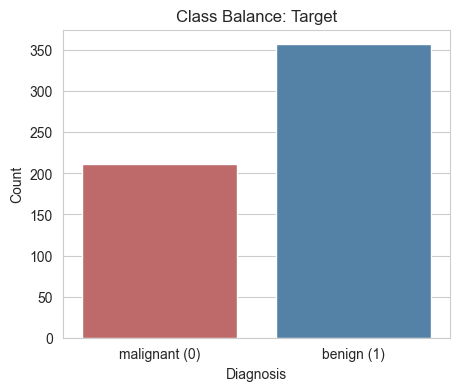

In [8]:
# Visualize class balance
plt.figure(figsize=(5, 4))
sns.countplot(x=y.map({0: 'malignant (0)', 1: 'benign (1)'}), palette=['indianred', 'steelblue'])
plt.title("Class Balance: Target")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


## Q3. Odds, Log-Odds, and the Logit Equation
Logistic regression models the log-odds of the positive class as a linear function of the predictors: `log(p / (1-p)) = β0 + β1x1 + ... + βnxn`. What do "odds" and "log-odds" mean in plain terms? Work through a numeric example: for a predicted probability of `p = 0.8`, calculate the corresponding odds and log-odds by hand, and explain how the sigmoid function (Q1) relates to this equation.


In [9]:
# Numeric example: p = 0.8
p = 0.8

odds = p / (1 - p)
log_odds = np.log(odds)

print(f"p (probability)      = {p}")
print(f"odds = p / (1-p)      = {odds}")
print(f"log-odds = log(odds)  = {log_odds:.4f}")

# Verify the sigmoid function recovers p from the log-odds (z)
z = log_odds
p_recovered = 1 / (1 + np.exp(-z))
print(f"\nsigmoid(log-odds) = {p_recovered:.4f}  (should match p = {p})")


p (probability)      = 0.8
odds = p / (1-p)      = 4.000000000000001
log-odds = log(odds)  = 1.3863

sigmoid(log-odds) = 0.8000  (should match p = 0.8)


86
## Q4. Train/Test Split, Scaling, and Model Fitting
Split the data into training (80%) and test (20%) sets using `train_test_split` with `random_state=42`. Scale the features using `StandardScaler`, fitting it on the training data only. Why must the scaler be fit on the training set only, and then used to transform the test set, rather than fitting a separate scaler on the test data? Fit a `LogisticRegression` model on the scaled training data and report the intercept and number of coefficients.


In [17]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create Train and Test Set
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)



print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# Fit the scaler ONLY on the training data

scaler=StandardScaler() 
# Use the SAME fitted scaler to transform the test data
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


# Fit logistic regression on the scaled training data
model=LogisticRegression()
model.fit(X_train,y_train)

print("\nIntercept (β0):", model.intercept_)
print("Number of coefficients:", model.coef_.shape[1])
print("\nFirst 5 coefficients:", model.coef_[0][:5])


Train shape: (455, 30)  Test shape: (114, 30)

Intercept (β0): [0.25515492]
Number of coefficients: 30

First 5 coefficients: [ 1.32158992  0.27853421  0.05242603 -0.00233866 -0.05146569]


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Q5. Predictions and the Confusion Matrix
Generate class predictions (`.predict`) and predicted probabilities (`.predict_proba`) for the test set. Build and visualize the confusion matrix. Label which cell corresponds to true positives, true negatives, false positives, and false negatives in this medical diagnosis context.


First 10 predicted classes:      [0 1 1 0 1 0 1 1 0 1]
First 10 predicted probabilities: [0.324 0.983 0.504 0.326 0.501 0.01  0.916 0.888 0.025 0.807]

Confusion Matrix (rows=actual, cols=predicted):
[[17 26]
 [28 43]]


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


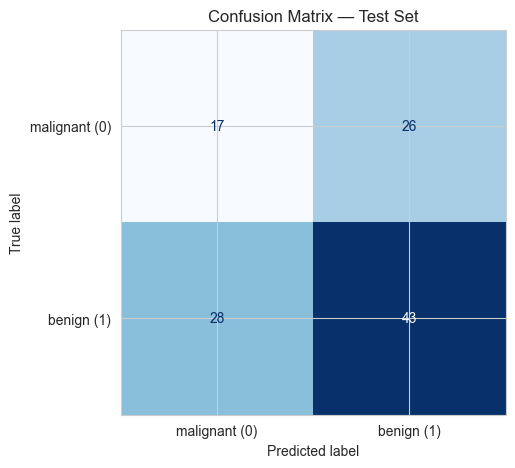


True Negatives  (correctly predicted malignant): 17
False Positives (predicted benign, actually malignant): 26
False Negatives (predicted malignant, actually benign): 28
True Positives  (correctly predicted benign): 43


In [18]:
# import metrics for evaluation
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score, classification_report,
                              roc_curve, auc)


# Evaluate the model on the test set
y_pred = model.predict(X_test_scaled)

y_proba = model.predict_proba(X_test_scaled)[:, 1]   # probability of class 1 (benign)

print("First 10 predicted classes:     ", y_pred[:10])
print("First 10 predicted probabilities:", np.round(y_proba[:10], 3))

# Compute and display the confusion matrix

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (rows=actual, cols=predicted):")
print(cm)


# Visualize the confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['malignant (0)', 'benign (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Test Set")
plt.show()

# Compute and display the confusion matrix values
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted malignant): {tn}")
print(f"False Positives (predicted benign, actually malignant): {fp}")
print(f"False Negatives (predicted malignant, actually benign): {fn}")
print(f"True Positives  (correctly predicted benign): {tp}")




## Q6. Classification Metrics and Their Clinical Cost
Compute Accuracy, Precision, Recall, and F1-score for the positive class. In this medical context (1 = benign, 0 = malignant), what does a false negative (predicting benign when the tumor is actually malignant) cost compared to a false positive (predicting malignant when the tumor is actually benign)? Which metric should be prioritized here, and why?


In [ ]:
# Compute Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

# Compute Precision
precision = precision_score(y_test, y_pred)   # for positive class (1 = benign)

# Compute Recall
recall = recall_score(y_test, y_pred)

# Compute F1-score
f1 = f1_score(y_test, y_pred)

# Display the evaluation metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# Display the full classification report

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=['malignant (0)', 'benign (1)']))


Accuracy:  0.5263
Precision: 0.6232
Recall:    0.6056
F1-score:  0.6143

Full classification report:
               precision    recall  f1-score   support

malignant (0)       0.38      0.40      0.39        43
   benign (1)       0.62      0.61      0.61        71

     accuracy                           0.53       114
    macro avg       0.50      0.50      0.50       114
 weighted avg       0.53      0.53      0.53       114




## Q7. ROC Curve and AUC
Plot the ROC (Receiver Operating Characteristic) curve for the test set predictions and compute the AUC (Area Under the Curve), including the diagonal "random guess" reference line. What does a curve close to the top-left corner indicate about the model, and what would an AUC of 0.5 mean?


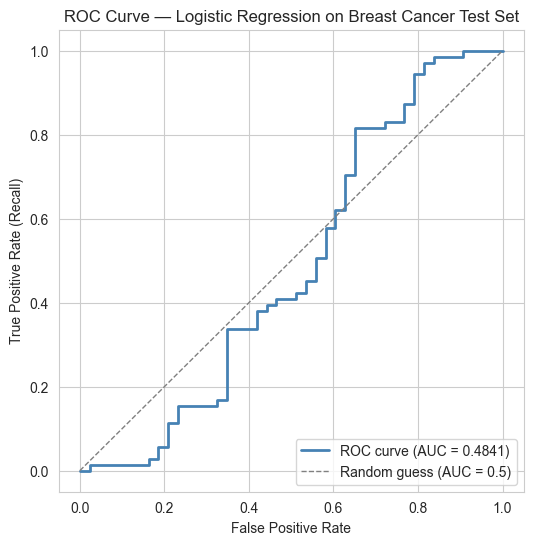

AUC: 0.4841


In [20]:
# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Visualize the ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Logistic Regression on Breast Cancer Test Set')
plt.legend(loc='lower right')
plt.show()

# Display the AUC value
print(f"AUC: {roc_auc:.4f}")
